# Mobile Price Classification

The goal is to classify the price range of a mobile phone (0 = low, 1 = medium, 2 = high, 3 = very high) from its specifications: battery power, RAM, screen size, camera resolution and others. The dataset has 2,000 phones and 20 features (`mobile_prices.csv`).

Reference solution: [Mobile Price Classification with Machine Learning](https://amanxai.com/2021/03/05/mobile-price-classification-with-machine-learning/) (Aman Kharwal). Dataset: [mobile_prices.csv](https://raw.githubusercontent.com/amankharwal/Website-data/master/mobile_prices.csv) (the Kaggle Mobile Price Classification data).

The reference trains a single Logistic Regression, scales the data before the split, and reports only an accuracy of 95.5%. Here several models from the course are compared, the errors are analysed per class, and the role of the strongest feature (RAM) is measured.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import os
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/Classification/mobile_price_classification')

## Data Loading

In [2]:
df = pd.read_csv("mobile_prices.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

In [3]:
df["price_range"].value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

## Data Cleaning

The classes are perfectly balanced (500 phones each), so accuracy is a fair metric here. There are no null values, but some zeros are impossible: a screen cannot be 0 cm wide, and a screen cannot have 0 pixels of height.

In [4]:
print((df[["px_height", "sc_w", "sc_h", "px_width"]] == 0).sum())
print("correlation of sc_w with price_range:", round(df["sc_w"].corr(df["price_range"]), 3))

px_height      2
sc_w         180
sc_h           0
px_width       0
dtype: int64
correlation of sc_w with price_range: 0.039


`sc_w` (screen width) is 0 in 180 phones (9%) and has almost no correlation with the price range, so the column is dropped instead of guessing 180 values. `px_height` is 0 in only 2 phones, so those rows are dropped.

In [5]:
df = df.drop(columns="sc_w")
df = df[df["px_height"] > 0].reset_index(drop=True)
df.shape

(1998, 20)

## Exploratory Data Analysis

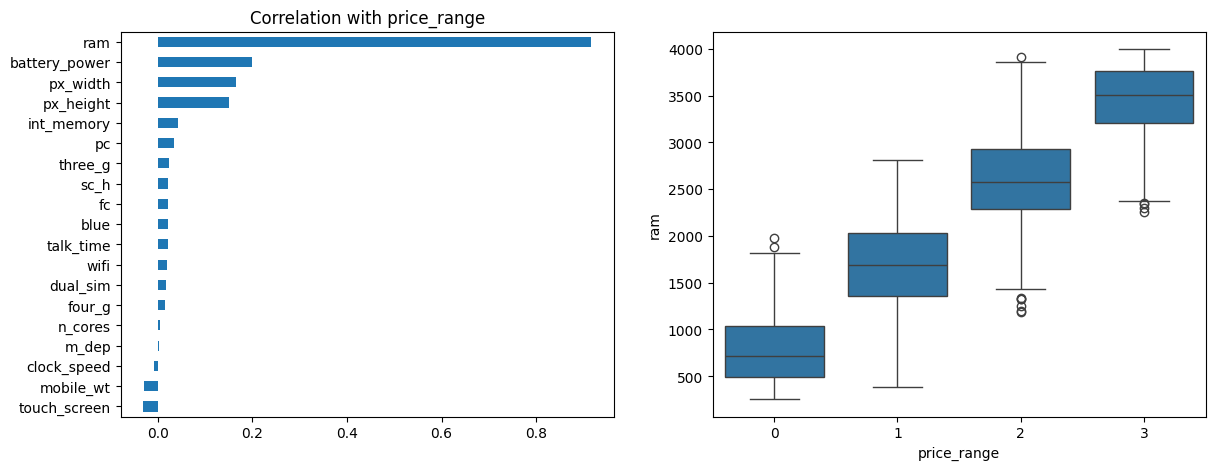

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df.corr()["price_range"].drop("price_range").sort_values().plot(kind="barh", ax=axes[0], title="Correlation with price_range")
sns.boxplot(x="price_range", y="ram", data=df, ax=axes[1])
plt.show()

RAM has a correlation of 0.92 with the price range, far above the second feature (battery power, 0.20). The boxplot shows that the RAM ranges of the four classes barely overlap. Most of the classification task is therefore decided by one feature.

## Feature Engineering

All features are numeric, so no encoding is needed. The split is 80/20 and stratified. The `StandardScaler` is fitted on the training set only, unlike the reference, which scales all the data before splitting.

In [7]:
x = df.drop(columns="price_range")
y = df["price_range"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler().fit(x_train)
x_train_s, x_test_s = scaler.transform(x_train), scaler.transform(x_test)
x_train.shape, x_test.shape

((1598, 19), (400, 19))

## Model Training

Six classifiers are trained and evaluated on the test set (macro F1 averages the F1 of the four classes).

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

def evaluate(model):
    pred = model.fit(x_train_s, y_train).predict(x_test_s)
    return {"Accuracy": accuracy_score(y_test, pred), "Macro F1": f1_score(y_test, pred, average="macro")}

pd.DataFrame({name: evaluate(model) for name, model in models.items()}).T.round(3)

,Accuracy,Macro F1
Logistic Regression,0.958,0.957
KNN,0.568,0.571
Naive Bayes,0.812,0.813
Decision Tree,0.800,0.801
Random Forest,0.888,0.887
Gradient Boosting,0.910,0.910


## Evaluation

A 5-fold cross-validation checks that the ranking does not depend on one split. The scaler is inside a pipeline so that it is refitted on the training part of each fold. `cross_validate` and `make_pipeline` were found while researching leakage-free validation and are not covered in class.

In [9]:
cv = {name: cross_validate(make_pipeline(StandardScaler(), model), x, y, cv=5, scoring=["accuracy", "f1_macro"])
      for name, model in models.items()}

pd.DataFrame({name: {m: f"{r[f'test_{m}'].mean():.3f} +/- {r[f'test_{m}'].std():.3f}" for m in ["accuracy", "f1_macro"]}
              for name, r in cv.items()}).T

,accuracy,f1_macro
Logistic Regression,0.964 +/- 0.006,0.964 +/- 0.006
KNN,0.524 +/- 0.020,0.524 +/- 0.020
Naive Bayes,0.811 +/- 0.020,0.811 +/- 0.019
Decision Tree,0.829 +/- 0.008,0.830 +/- 0.007
Random Forest,0.879 +/- 0.009,0.879 +/- 0.009
Gradient Boosting,0.899 +/- 0.014,0.899 +/- 0.013


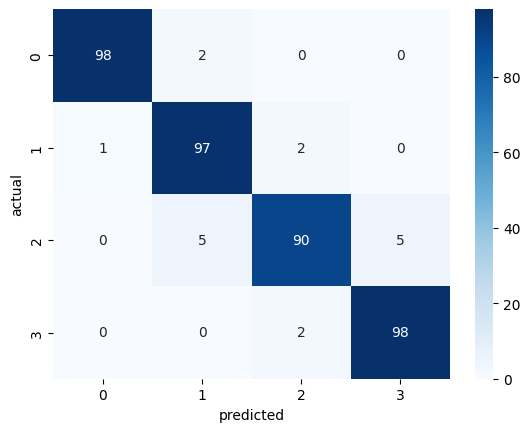

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       100
           1       0.93      0.97      0.95       100
           2       0.96      0.90      0.93       100
           3       0.95      0.98      0.97       100

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400

share of errors that are off by exactly one price range: 1.0


In [10]:
best = models["Logistic Regression"].fit(x_train_s, y_train)
pred = best.predict(x_test_s)

sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("predicted"); plt.ylabel("actual"); plt.show()
print(classification_report(y_test, pred))
print("share of errors that are off by exactly one price range:", (np.abs(y_test - pred)[y_test != pred] == 1).mean())

The price range is ordered, and a wrong prediction is less serious when it lands in the neighbouring class. The last line shows what share of the errors are of that kind. Next, how much of the result comes from RAM alone, and which features the Random Forest uses.

Logistic Regression with RAM only (5-fold accuracy): 0.755


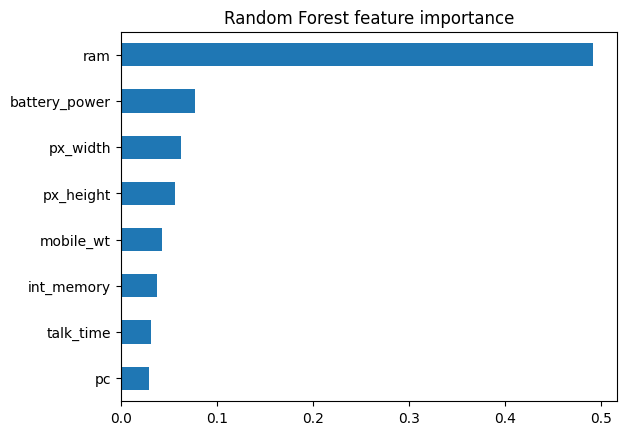

In [11]:
ram_only = cross_validate(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)), x[["ram"]], y, cv=5)["test_score"].mean()
print("Logistic Regression with RAM only (5-fold accuracy):", round(ram_only, 3))

forest = RandomForestClassifier(random_state=42).fit(x_train, y_train)
pd.Series(forest.feature_importances_, index=x.columns).sort_values().tail(8).plot(kind="barh", title="Random Forest feature importance")
plt.show()

The reference is reproduced for comparison: scaling before the split, `random_state=0`, Logistic Regression, on the original 2,000 rows.

In [12]:
raw = pd.read_csv("mobile_prices.csv")
ref_x = StandardScaler().fit_transform(raw.iloc[:, :-1])
ref_x_train, ref_x_test, ref_y_train, ref_y_test = train_test_split(ref_x, raw["price_range"], test_size=0.20, random_state=0)
ref_pred = LogisticRegression().fit(ref_x_train, ref_y_train).predict(ref_x_test)
print("reference-style accuracy:", accuracy_score(ref_y_test, ref_pred))

reference-style accuracy: 0.955


## Conclusion

**Reference approach.** The reference trains a Logistic Regression on all features with a `StandardScaler` fitted on the whole dataset before the split, and reports one accuracy (95.5%). The data has no null values and balanced classes (500 phones per price range), so accuracy is a fair metric, but the reference shows no per-class results, compares no other model, and prints the count of predicted classes, which says nothing about correctness. Reproducing it with the same seed gave exactly 0.955.

**Data.** `sc_w` (screen width) is 0 for 180 phones, which is impossible, and it has almost no correlation with the price range (0.04), so the column was dropped. Two phones with a pixel height of 0 were removed.

**Models.** Stratified 80/20 split with a training-only scaler, and 5-fold cross-validation with the scaler inside each fold:

| Model | Test accuracy | CV accuracy |
|---|---|---|
| Logistic Regression | 0.958 | 0.964 +/- 0.006 |
| Gradient Boosting | 0.908 | 0.899 +/- 0.014 |
| Random Forest | 0.888 | 0.879 +/- 0.009 |
| Decision Tree | 0.800 | 0.829 +/- 0.008 |
| Naive Bayes | 0.812 | 0.811 +/- 0.020 |
| KNN | 0.568 | 0.524 +/- 0.020 |

The reference's choice of Logistic Regression turns out to be the best of the six models, by about 6 points over the next one. The price range in this dataset behaves like a weighted sum of the specifications, which suits a linear model, while trees need many splits to approximate a slanted boundary. KNN fails because 19 scaled features, most of them unrelated to the price, make all phones look equally far from each other.

**Where the signal is.** RAM has a correlation of 0.92 with the price range and dominates the Random Forest importance. A Logistic Regression using RAM alone reaches an accuracy of 0.755, so RAM explains most of the structure, and the remaining features (battery power and screen pixels first) lift the accuracy to about 0.96.

**Errors.** In the confusion matrix, all the errors are between neighbouring price ranges (100% off by exactly one class). The weakest class is 2 (recall 0.90), mostly confused with the classes next to it.

**Limitations.** The dataset looks synthetic (balanced classes, no missing values, a very clean relation with RAM), so the high accuracy should not be expected on real phone prices, where brand and market timing matter. No hyperparameters were tuned.